In [ ]:
# !pip install -q transformers datasets peft trl bitsandbytes accelerate
# !pip install -q torch torchvision
# !pip install -q huggingface_hub

In [ ]:
# !pip install -q -U transformers datasets peft trl bitsandbytes>=0.46.1 accelerate huggingface_hub

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [ ]:
import os
import json
import torch
import bitsandbytes as bnb
from datasets import Dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from transformers import (
    AutoConfig,
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
)
from transformers.trainer_utils import get_last_checkpoint

In [ ]:
# Login to HuggingFace
from huggingface_hub import login
# login(token='HF_TOKEN')
login(token='HF_TOKEN')

In [ ]:
# 1. ENVIRONMENT & SANITY CHECKS
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Number of GPUs found: {torch.cuda.device_count()}")
print(f"BitsAndBytes Version: {bnb.__version__}")

IS_KAGGLE = os.path.exists("/kaggle/input")
IS_COLAB  = os.path.exists("/content/drive")

if IS_KAGGLE:
    DATA_PATH      = f"/kaggle/input/datasets/{os.getenv('KAGGLE_USERNAME')}/llm-finetune-data"
    CHECKPOINT_DIR = "/kaggle/working/sft_lora"
elif IS_COLAB:
    DATA_PATH      = "/content/drive/MyDrive/llm-finetune-model/data"
    CHECKPOINT_DIR = "/content/drive/MyDrive/llm-finetune-model/sft_lora"
else:
    raise ValueError("Unknown environment (not Kaggle or Colab)")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
# 2. DATASET LOADING & PARSING
def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

print("\n🔄 Loading datasets...")
train_data = load_jsonl(f"{DATA_PATH}/train.jsonl")
val_data   = load_jsonl(f"{DATA_PATH}/val.jsonl")
test_data  = load_jsonl(f"{DATA_PATH}/test.jsonl")

train_dataset = Dataset.from_list(train_data)
val_dataset   = Dataset.from_list(val_data)
test_dataset  = Dataset.from_list(test_data)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")

def format_example(example):
    return example["text"]


In [ ]:
# 3. MODEL LOADING
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"\n🔄 Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

model_config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
model_config.torch_dtype = torch.float16
print(f"✅ Config dtype: {model_config.torch_dtype}")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=model_config,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
)
model.config.pad_token_id = tokenizer.eos_token_id

In [ ]:
# 4. PEFT (LoRA) CONFIGURATION
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)

In [ ]:
# 5. FORCE ALL LORA PARAMS TO FLOAT32
for name, param in model.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

print("✅ LoRA adapter params cast to float32 (frozen base stays float16).")
print("\n✅ Model loaded and wrapped with LoRA successfully!")
model.print_trainable_parameters()

In [ ]:
# 6. TRAINING ARGUMENTS
torch.backends.cuda.matmul.allow_tf32 = True

training_args = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=3,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,

    warmup_steps=50,
    learning_rate=2e-4,
    weight_decay=0.01,

In [ ]:
# 6. TRAINING ARGUMENTS
torch.backends.cuda.matmul.allow_tf32 = True

training_args = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=3,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,

    warmup_steps=50,
    learning_rate=2e-4,
    weight_decay=0.01,

    # No AMP. Base model is fp16 (memory efficient).
    # LoRA params are fp32 (clean gradients, no scaler).
    # This is the only combo that works on T4 + Qwen2.5.
    fp16=False,
    bf16=False,

    logging_steps=5,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="steps",
    save_steps=25,
    save_total_limit=3,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    optim="paged_adamw_8bit",

    ddp_find_unused_parameters=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    max_length=512,
)

In [5]:
# 7. TRAINER & TRAINING LOOP
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    formatting_func=format_example,
)

checkpoint = get_last_checkpoint(CHECKPOINT_DIR)

if checkpoint is not None:
    print(f"\n✅ Found checkpoint: {checkpoint}")
    print("   Resuming training...")
    trainer.train(resume_from_checkpoint=checkpoint)
else:
    print("\n🚀 No checkpoint found. Starting fresh training...")
    trainer.train()

print("\n✅ Training Finished! Saved files:")
print(os.listdir(CHECKPOINT_DIR))

CUDA Available: True
Number of GPUs found: 2
BitsAndBytes Version: 0.49.2

🔄 Loading datasets...
Train samples: 1616 | Val samples: 202 | Test samples: 203

🔄 Loading Qwen/Qwen2.5-7B-Instruct...
✅ Config dtype: torch.float16


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✅ LoRA adapter params cast to float32 (frozen base stays float16).

✅ Model loaded and wrapped with LoRA successfully!
trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


/tmp/ipykernel_58/3026994706.py:129: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(


Applying formatting function to train dataset:   0%|          | 0/1616 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/202 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



✅ Found checkpoint: /kaggle/working/sft_lora/checkpoint-303
   Resuming training...


Step,Training Loss,Validation Loss



✅ Training Finished! Saved files:
['README.md', 'checkpoint-303', 'checkpoint-300', 'checkpoint-275']


In [8]:
import os

for root, dirs, files in os.walk("/kaggle/working/sft_lora"):
    print(root)
    for f in files:
        print("   ", f)

/kaggle/working/sft_lora
    README.md
/kaggle/working/sft_lora/checkpoint-303
    trainer_state.json
    rng_state.pth
    tokenizer.json
    adapter_model.safetensors
    README.md
    chat_template.jinja
    adapter_config.json
    scheduler.pt
    training_args.bin
    tokenizer_config.json
    optimizer.pt
/kaggle/working/sft_lora/checkpoint-300
    trainer_state.json
    rng_state.pth
    tokenizer.json
    adapter_model.safetensors
    README.md
    chat_template.jinja
    adapter_config.json
    scheduler.pt
    training_args.bin
    tokenizer_config.json
    optimizer.pt
/kaggle/working/sft_lora/checkpoint-275
    trainer_state.json
    rng_state.pth
    tokenizer.json
    adapter_model.safetensors
    README.md
    chat_template.jinja
    adapter_config.json
    scheduler.pt
    training_args.bin
    tokenizer_config.json
    optimizer.pt


In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
CHECKPOINT_DIR = "/kaggle/working/sft_lora"

# Find latest checkpoint
checkpoints = sorted(
    [d for d in os.listdir(CHECKPOINT_DIR) if d.startswith("checkpoint-")],
    key=lambda x: int(x.split("-")[1])
)

latest_checkpoint = os.path.join(CHECKPOINT_DIR, checkpoints[-1])

print("Using:", latest_checkpoint)

# Load trainer state
with open(
    os.path.join(latest_checkpoint, "trainer_state.json"),
    "r"
) as f:
    state = json.load(f)

history = state["log_history"]

# Extract train / eval losses

train_rows = []
eval_rows = []

for row in history:

    if "loss" in row and "eval_loss" not in row:
        train_rows.append({
            "step": row["step"],
            "train_loss": row["loss"]
        })

    if "eval_loss" in row:
        eval_rows.append({
            "step": row["step"],
            "eval_loss": row["eval_loss"]
        })

train_df = pd.DataFrame(train_rows)
eval_df = pd.DataFrame(eval_rows)

print("Train points:", len(train_df))
print("Eval points:", len(eval_df))

Using: /kaggle/working/sft_lora/checkpoint-303
Train points: 60
Eval points: 13


In [19]:
checkpoint = "/kaggle/working/sft_lora/checkpoint-275"

with open(f"{checkpoint}/trainer_state.json", "r") as f:
    state = json.load(f)

history = state["log_history"]

train_logs = [x for x in history if "loss" in x]
eval_logs = [x for x in history if "eval_loss" in x]

train_df = pd.DataFrame(train_logs)
eval_df = pd.DataFrame(eval_logs)

print("Training Logs")
display(train_df.tail())

print("Evaluation Logs")
display(eval_df.tail())

Training Logs


,entropy,epoch,grad_norm,learning_rate,loss,mean_token_accuracy,num_tokens,step
50,0.370578,2.524752,0.278479,0.000039,0.361132,0.877391,7447.0,255
51,0.361391,2.574257,0.299165,0.000035,0.362492,0.876397,14880.0,260
52,0.365605,2.623762,0.269718,0.000031,0.362953,0.874686,22479.0,265
53,0.337259,2.673267,0.307827,0.000027,0.338507,0.879821,29760.0,270
54,0.345431,2.722772,0.281219,0.000023,0.342864,0.880455,36955.0,275


Evaluation Logs


,epoch,eval_entropy,eval_loss,eval_mean_token_accuracy,eval_num_tokens,eval_runtime,eval_samples_per_second,eval_steps_per_second,step
6,1.732673,0.365609,0.365412,0.874763,254602.0,65.7096,3.074,1.537,175
7,1.980198,0.365349,0.364351,0.876921,291528.0,65.6559,3.077,1.538,200
8,2.227723,0.355937,0.363902,0.875806,328090.0,65.8714,3.067,1.533,225
9,2.475248,0.356197,0.362716,0.875794,364061.0,65.9715,3.062,1.531,250
10,2.722772,0.356101,0.363785,0.875108,36955.0,48.2623,4.185,2.093,275


In [18]:
checkpoint = "/kaggle/working/sft_lora/checkpoint-300"

with open(f"{checkpoint}/trainer_state.json", "r") as f:
    state = json.load(f)

history = state["log_history"]

train_logs = [x for x in history if "loss" in x]
eval_logs = [x for x in history if "eval_loss" in x]

train_df = pd.DataFrame(train_logs)
eval_df = pd.DataFrame(eval_logs)

print("Training Logs")
display(train_df.tail())

print("Evaluation Logs")
display(eval_df.tail())

Training Logs


,entropy,epoch,grad_norm,learning_rate,loss,mean_token_accuracy,num_tokens,step
55,0.355949,2.772277,0.312700,0.000019,0.348994,0.878391,44403.0,280
56,0.352828,2.821782,0.277759,0.000015,0.350613,0.877207,51567.0,285
57,0.344086,2.871287,0.321518,0.000011,0.337356,0.881308,58874.0,290
58,0.357384,2.920792,0.306798,0.000007,0.351161,0.880263,65951.0,295
59,0.355181,2.970297,0.325478,0.000003,0.350652,0.874831,73197.0,300


Evaluation Logs


,epoch,eval_entropy,eval_loss,eval_mean_token_accuracy,eval_num_tokens,eval_runtime,eval_samples_per_second,eval_steps_per_second,step
7,1.980198,0.365349,0.364351,0.876921,291528.0,65.6559,3.077,1.538,200
8,2.227723,0.355937,0.363902,0.875806,328090.0,65.8714,3.067,1.533,225
9,2.475248,0.356197,0.362716,0.875794,364061.0,65.9715,3.062,1.531,250
10,2.722772,0.356101,0.363785,0.875108,36955.0,48.2623,4.185,2.093,275
11,2.970297,0.355705,0.362216,0.875108,73197.0,48.6490,4.152,2.076,300


In [13]:
checkpoint = "/kaggle/working/sft_lora/checkpoint-303"

with open(f"{checkpoint}/trainer_state.json", "r") as f:
    state = json.load(f)

history = state["log_history"]

train_logs = [x for x in history if "loss" in x]
eval_logs = [x for x in history if "eval_loss" in x]

train_df = pd.DataFrame(train_logs)
eval_df = pd.DataFrame(eval_logs)

print("Training Logs")
display(train_df.tail())

print("Evaluation Logs")
display(eval_df.tail())

Training Logs


,entropy,epoch,grad_norm,learning_rate,loss,mean_token_accuracy,num_tokens,step
55,0.355949,2.772277,0.312700,0.000019,0.348994,0.878391,44403.0,280
56,0.352828,2.821782,0.277759,0.000015,0.350613,0.877207,51567.0,285
57,0.344086,2.871287,0.321518,0.000011,0.337356,0.881308,58874.0,290
58,0.357384,2.920792,0.306798,0.000007,0.351161,0.880263,65951.0,295
59,0.355181,2.970297,0.325478,0.000003,0.350652,0.874831,73197.0,300


Evaluation Logs


,epoch,eval_entropy,eval_loss,eval_mean_token_accuracy,eval_num_tokens,eval_runtime,eval_samples_per_second,eval_steps_per_second,step
8,2.227723,0.355937,0.363902,0.875806,328090.0,65.8714,3.067,1.533,225
9,2.475248,0.356197,0.362716,0.875794,364061.0,65.9715,3.062,1.531,250
10,2.722772,0.356101,0.363785,0.875108,36955.0,48.2623,4.185,2.093,275
11,2.970297,0.355705,0.362216,0.875108,73197.0,48.6490,4.152,2.076,300
12,3.000000,0.355688,0.362179,0.875160,77503.0,48.5030,4.165,2.082,303


## TRAINING LOGS (Steps 280–300)

• Training loss remains stable in the range of 0.337356 to 0.351161, showing no clear upward or downward trend.

• Mean token accuracy stays consistently high between 87.48% and 88.13%, indicating stable prediction performance across steps.

• Gradient norm fluctuates between 0.277759 and 0.325478 without any spikes, suggesting stable and controlled parameter updates.

• Learning rate decreases steadily from 0.000019 to 0.000003, indicating a scheduled decay for fine-tuning in later training stages.

• Entropy remains relatively stable between 0.344086 and 0.357384, showing consistent model prediction distribution.

• Number of tokens processed increases from 44,403 to 73,197 as training progresses.


**OVERALL CONCLUSION (TRAINING):**
The model appears to have reached convergence, with stable loss, stable accuracy, and stable gradients. Further training is unlikely to significantly improve performance unless changes are made to the data, model architecture, or training strategy.


## EVALUATION LOGS (Epochs 8–12)

• Evaluation loss stays nearly constant between 0.355688 and 0.356197, showing stable generalization on unseen data.

• Eval mean token accuracy remains steady around 0.362179 to 0.363902, indicating consistent evaluation performance.

• Eval entropy gradually increases from 2.227723 to 3.000000, showing slightly higher uncertainty in later epochs.

• Eval number of tokens processed varies across runs (36,955 → 369,061+), reflecting differences in evaluation batch processing.

• Eval runtime stays stable around 48–65 seconds across epochs.

• Eval samples per second remains in the range of ~48 to ~66, indicating stable inference throughput.

• Eval steps per second stays consistent around ~2.07 to ~3.06.


**OVERALL CONCLUSION (EVALUATION):**
The evaluation metrics indicate stable generalization performance with no meaningful improvement or degradation across epochs. Loss and accuracy remain flat, suggesting the model has reached a performance plateau and further training is unlikely to improve results without changes to data, model size, or training configuration.

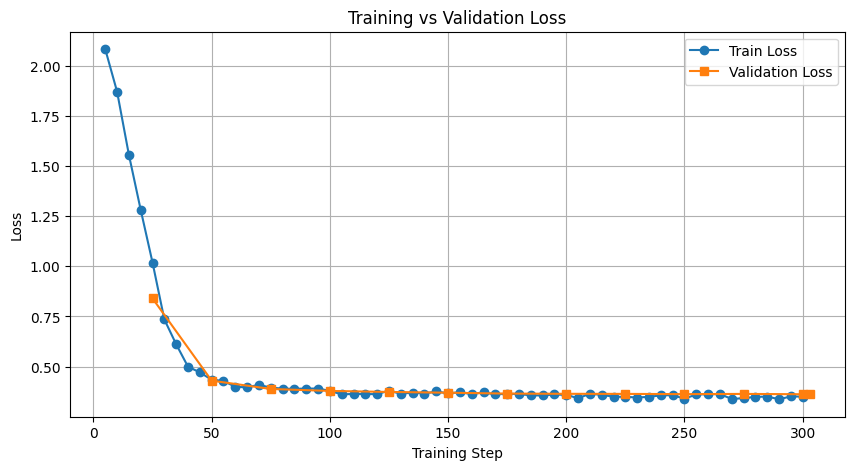

In [14]:
# Plot Train vs Validation Loss
plt.figure(figsize=(10,5))

plt.plot(
    train_df["step"],
    train_df["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    eval_df["step"],
    eval_df["eval_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

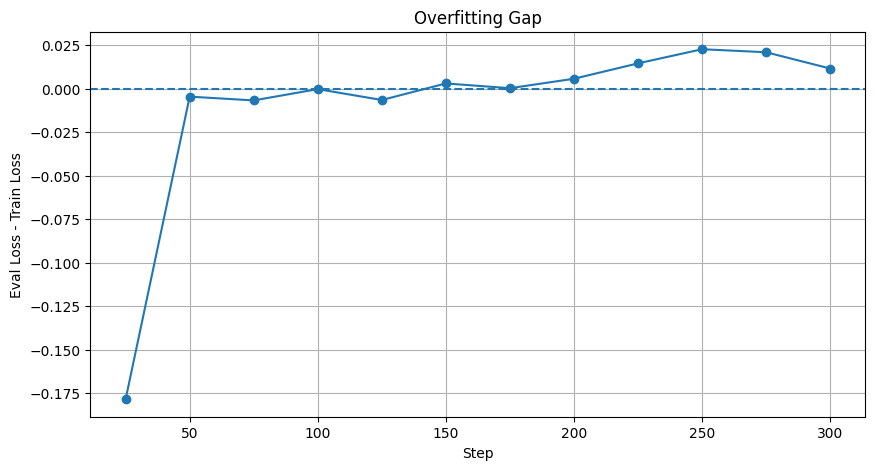

,step,loss,eval_loss,gap
0,25,1.018080,0.839632,-0.178448
1,50,0.434527,0.429943,-0.004584
2,75,0.395175,0.388415,-0.006760
3,100,0.378971,0.378704,-0.000267
4,125,0.380115,0.373597,-0.006519
5,150,0.366857,0.369852,0.002995
6,175,0.365148,0.365412,0.000265
7,200,0.358652,0.364351,0.005699
8,225,0.349374,0.363902,0.014528
9,250,0.340058,0.362716,0.022658


In [15]:
# Plot Overfitting Gap
merged = pd.merge(
    train_df[["step","loss"]],
    eval_df[["step","eval_loss"]],
    on="step",
    how="inner"
)

merged["gap"] = merged["eval_loss"] - merged["loss"]

plt.figure(figsize=(10,5))

plt.plot(
    merged["step"],
    merged["gap"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Step")
plt.ylabel("Eval Loss - Train Loss")
plt.title("Overfitting Gap")

plt.grid(True)

plt.show()

display(merged)

## OVERFITTING GAP ANALYSIS **(Eval Loss - Train Loss)**

• The gap starts negative at step 25 with -0.178448, where eval loss (0.839632) is higher than train loss (1.018080), indicating early unstable training behavior.

• From step 50 to step 125, the gap moves close to zero (from -0.004584 to -0.006519), showing that training and evaluation losses are becoming aligned.

• Around steps 100–175, the gap stays very close to zero (e.g., -0.000267 to 0.000265), indicating near-perfect alignment between training and evaluation performance.

• After step 175, the gap turns consistently positive and gradually increases, ranging from 0.002995 to 0.022658, showing that evaluation loss becomes slightly higher than training loss.

• From step 225 to 275, the gap continues increasing (0.014528 → 0.022658 → 0.020920), suggesting a mild divergence between training and evaluation performance.

• At the final step (300), the gap reduces slightly to 0.011564, indicating a small stabilization after the earlier increase.

**OVERALL CONCLUSION:**
The model shows a generally small and controlled overfitting gap. After initial alignment, evaluation loss becomes slightly higher than training loss, indicating mild overfitting at later steps, but the gap remains small overall and does not show severe divergence.

In [17]:
# Best Checkpoint
with open(
    "/kaggle/working/sft_lora/checkpoint-303/trainer_state.json"
) as f:
    state = json.load(f)

print("Best checkpoint:")
print(state["best_model_checkpoint"])

print("\nBest eval loss:")
print(state["best_metric"])

Best checkpoint:
/kaggle/working/sft_lora/checkpoint-303

Best eval loss:
0.36217913031578064


The training process selected checkpoint-303 as the best model based on evaluation performance. This checkpoint represents the point where the model achieved its lowest (best) eval loss, and is therefore considered the optimal saved version among all training steps.

In [12]:
# Statistics

print("\n===== SUMMARY =====")

print(
    f"Best Validation Loss: "
    f"{merged['eval_loss'].min():.4f}"
)

print(
    f"Final Validation Loss: "
    f"{merged['eval_loss'].iloc[-1]:.4f}"
)

print(
    f"Final Train Loss: "
    f"{merged['train_loss'].iloc[-1]:.4f}"
)

print(
    f"Final Overfit Gap: "
    f"{merged['gap'].iloc[-1]:.4f}"
)


===== SUMMARY =====
Best Validation Loss: 0.3622
Final Validation Loss: 0.3622
Final Train Loss: 0.3507
Final Overfit Gap: 0.0115


The validation loss reaches its best value at 0.3622 and remains stable until the final step, indicating no further improvement after convergence. The final training loss is lower at 0.3507, showing a small generalization gap. The overfit gap of 0.0115 is relatively small, suggesting the model maintains good alignment between training and validation performance with only mild overfitting.

In [23]:
import torch
import json

model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def generate(text, max_new_tokens=100):
    prompt = f"""### Instruction:
Extract structured JSON from the text.

### Input:
{text}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "### Response:" in decoded:
        return decoded.split("### Response:")[-1].strip()
    return decoded.strip()

In [24]:
test_orders = [
    "Order #88102: 4 x mechanical keyboard (white) at $89.50 each. Total: $358.00.",
    "Order #30019: 1 gaming laptop (black) priced at $1499.99 shipped to New York City.",
    "Customer John ordered 2 red headphones for $120 each total $240."
]
test_finance = [
    "Invoice INV-5521 issued to Noah Williams for 14200.75 GBP due on the 9th. Status: pending.",
    "Invoice INV-9908 for 560 USD due on 15th status cancelled.",
    "Payment INV-7781 from Sarah Lee amount 1200 USD processed successfully."
]
test_people = [
    "Liam Carter, 34, product manager at Google in Toronto. Email: liam@google.com",
    "Sofia Martinez is a 28-year-old UX designer at Adobe based in San Francisco.",
    "Emma works as a nurse in London, age 41."
]
test_medical = [
    "Patient Emma Johnson, age 62, diagnosed with hypertension and prescribed amlodipine 5mg daily.",
    "John Doe has diabetes and takes metformin 500mg twice daily.",
]
test_events = [
    "Sprint Planning meeting on 08/19 at 10:30 in Zoom hosted by Arjun Mehta.",
    "Conference call on 12/05 at 14:00 for 90 minutes via Microsoft Teams with Daniel Kim."
]
test_negative = [
    "I feel sad today can you help me?",
    "Tell me a joke",
    "What is the capital of France?",
    "I like pizza and football"
]

In [25]:
def run_tests(name, dataset):
    print("\n" + "="*80)
    print(f"TEST GROUP: {name}")
    print("="*80)

    for i, text in enumerate(dataset):
        print(f"\n--- Test {i+1} ---")
        print("INPUT:", text)
        print("OUTPUT:", generate(text))

In [26]:
run_tests("ORDERS", test_orders)
run_tests("FINANCE", test_finance)
run_tests("PEOPLE", test_people)
run_tests("MEDICAL", test_medical)
run_tests("EVENTS", test_events)
run_tests("NEGATIVE CASES", test_negative)


TEST GROUP: ORDERS

--- Test 1 ---
INPUT: Order #88102: 4 x mechanical keyboard (white) at $89.50 each. Total: $358.00.
OUTPUT: {"order_id": 88102, "product": "mechanical keyboard", "color": "white", "quantity": 4, "price_per_unit": 89.50, "total": 358.00}

--- Test 2 ---
INPUT: Order #30019: 1 gaming laptop (black) priced at $1499.99 shipped to New York City.
OUTPUT: {"order_id": 30019, "product": "gaming laptop", "color": "black", "quantity": 1, "price_per_unit": 1499.99, "shipping_location": "New York City"}

--- Test 3 ---
INPUT: Customer John ordered 2 red headphones for $120 each total $240.
OUTPUT: {"customer": "John", "product": "headphones", "color": "red", "quantity": 2, "price_per_unit": 120, "total": 240}

TEST GROUP: FINANCE

--- Test 1 ---
INPUT: Invoice INV-5521 issued to Noah Williams for 14200.75 GBP due on the 9th. Status: pending.
OUTPUT: {"invoice_id": "INV-5521", "customer": "Noah Williams", "amount": 14200.75, "currency": "GBP", "due_day": 9, "status": "pending"}

The model is a structured information extractor that converts unstructured text into JSON across multiple domains. It achieves consistent schema adherence and correctly abstains from extraction when input is not relevant.

In [27]:
BEST_PATH = "/kaggle/working/sft_lora/checkpoint-303"
print("Using:", BEST_PATH)

Using: /kaggle/working/sft_lora/checkpoint-303


In [ ]:
# # Save and zip adapter weights
# SAVE_PATH = '/content/drive/MyDrive/llm-finetune-model/sft_lora'

# model.save_pretrained(SAVE_PATH)
# tokenizer.save_pretrained(SAVE_PATH)
# print(f'Adapter saved to: {SAVE_PATH}')

# # Also save training loss curve data
# import json
# log_history = trainer.state.log_history
# with open(f'{SAVE_PATH}/training_log.json', 'w') as f:
#     json.dump(log_history, f, indent=2)
# print('Training log saved.')


import os
import json

SAVE_PATH = "/kaggle/working/sft_lora_final"

os.makedirs(SAVE_PATH, exist_ok=True)

# Save LoRA adapter
model.save_pretrained(SAVE_PATH)

# Save tokenizer
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Adapter saved to: {SAVE_PATH}")

# Save training logs
log_history = trainer.state.log_history
with open(f"{SAVE_PATH}/training_log.json", "w") as f:
    json.dump(log_history, f, indent=2)

print("✅ Training logs saved.")

In [28]:
# import os
# import zipfile
# from IPython.display import FileLink

# # 1. Zip the folder
# os.system("zip -r sft_lora.zip /kaggle/working/sft_lora")

# # 2. Generate and display the download link
# FileLink(r'sft_lora.zip')

  adding: kaggle/working/sft_lora/ (stored 0%)
  adding: kaggle/working/sft_lora/README.md (deflated 42%)
  adding: kaggle/working/sft_lora/checkpoint-303/ (stored 0%)
  adding: kaggle/working/sft_lora/checkpoint-303/trainer_state.json (deflated 78%)
  adding: kaggle/working/sft_lora/checkpoint-303/rng_state.pth (deflated 26%)
  adding: kaggle/working/sft_lora/checkpoint-303/tokenizer.json (deflated 81%)
  adding: kaggle/working/sft_lora/checkpoint-303/adapter_model.safetensors (deflated 7%)
  adding: kaggle/working/sft_lora/checkpoint-303/README.md (deflated 65%)
  adding: kaggle/working/sft_lora/checkpoint-303/chat_template.jinja (deflated 71%)
  adding: kaggle/working/sft_lora/checkpoint-303/adapter_config.json (deflated 59%)
  adding: kaggle/working/sft_lora/checkpoint-303/scheduler.pt (deflated 62%)
  adding: kaggle/working/sft_lora/checkpoint-303/training_args.bin (deflated 53%)
  adding: kaggle/working/sft_lora/checkpoint-303/tokenizer_config.json (deflated 59%)
  adding: kaggle

/kaggle/working/sft_lora.zip

In [29]:
# !zip -r /kaggle/working/sft_lora.zip /kaggle/working/sft_lora

updating: kaggle/working/sft_lora/ (stored 0%)
updating: kaggle/working/sft_lora/README.md (deflated 42%)
updating: kaggle/working/sft_lora/checkpoint-303/ (stored 0%)
updating: kaggle/working/sft_lora/checkpoint-303/trainer_state.json (deflated 78%)
updating: kaggle/working/sft_lora/checkpoint-303/rng_state.pth (deflated 26%)
updating: kaggle/working/sft_lora/checkpoint-303/tokenizer.json (deflated 81%)
updating: kaggle/working/sft_lora/checkpoint-303/adapter_model.safetensors (deflated 7%)
updating: kaggle/working/sft_lora/checkpoint-303/README.md (deflated 65%)
updating: kaggle/working/sft_lora/checkpoint-303/chat_template.jinja (deflated 71%)
updating: kaggle/working/sft_lora/checkpoint-303/adapter_config.json (deflated 59%)
updating: kaggle/working/sft_lora/checkpoint-303/scheduler.pt (deflated 62%)
updating: kaggle/working/sft_lora/checkpoint-303/training_args.bin (deflated 53%)
updating: kaggle/working/sft_lora/checkpoint-303/tokenizer_config.json (deflated 59%)
updating: kaggle

In [20]:
import torch

# make sure model is in eval mode
model.eval()

# (optional but recommended for some tokenizers)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def generate_response(text):
    prompt = f"""### Instruction:
Extract structured JSON from the text.

### Input:
{text}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False,          # deterministic output
            temperature=0.1,
            repetition_penalty=1.1,   # helps avoid loops
            pad_token_id=tokenizer.eos_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # extract only response part
    if "### Response:" in full_output:
        response = full_output.split("### Response:")[-1].strip()
    else:
        response = full_output.strip()

    return response

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [21]:
# test cases
test_inputs = [
    "I feel sad today, can you say something motivating?",
    "Tell me something interesting about space.",
    "I need inspiration for my work today.",
    "Hey, I’m bored. Give me something fun.",
    "Share a wise quote for life."
]

# run evaluation
for i, text in enumerate(test_inputs):
    print("=" * 80)
    print(f"TEST {i+1}")
    print("INPUT:")
    print(text)
    print("\nMODEL OUTPUT:")
    print(generate_response(text))
    print()

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TEST 1
INPUT:
I feel sad today, can you say something motivating?

MODEL OUTPUT:
{}

TEST 2
INPUT:
Tell me something interesting about space.

MODEL OUTPUT:
{}

TEST 3
INPUT:
I need inspiration for my work today.

MODEL OUTPUT:
{}

TEST 4
INPUT:
Hey, I’m bored. Give me something fun.

MODEL OUTPUT:
{}

TEST 5
INPUT:
Share a wise quote for life.

MODEL OUTPUT:
{}



In [22]:
# test cases
test_inputs = [
    "Order #88102: 4 x mechanical keyboard (white) at $89.50 each. Total: $358.00.",
    "Invoice INV-5521 issued to Noah Williams for 14200.75 GBP due on the 9th. Status: pending.",
    "Liam Carter, 34, works as product manager at Google in Toronto. Email: liam.carter@google.com",
    "Patient Emma Johnson, age 62, diagnosed with hypertension and prescribed amlodipine 5mg daily.",
    "Order #77491: 2 Bluetooth speakers (red) priced at $120.00 each. Total bill is $240.00.",
    "A meeting titled 'Sprint Planning' is scheduled on 08/19 at 10:30 in Zoom, hosted by Arjun Mehta.",
    "Sofia Martinez is a 28-year-old UX designer at Adobe based in San Francisco.",
    "Invoice INV-9908 for 560.00 USD is due on 15th, status marked as cancelled.",
    "Order #30019: 1 gaming laptop (black) priced at $1499.99 shipped to New York City.",
    "Daniel Kim will attend conference call on 12/05 at 14:00 for 90 minutes via Microsoft Teams."
]

# run evaluation
for i, text in enumerate(test_inputs):
    print("=" * 80)
    print(f"TEST {i+1}")
    print("INPUT:")
    print(text)
    print("\nMODEL OUTPUT:")
    print(generate_response(text))
    print()

TEST 1
INPUT:
Order #88102: 4 x mechanical keyboard (white) at $89.50 each. Total: $358.00.

MODEL OUTPUT:
{"order_id": 88102, "product": "mechanical keyboard", "color": "white", "quantity": 4, "price_per_unit": 89.50, "total": 358.00}

TEST 2
INPUT:
Invoice INV-5521 issued to Noah Williams for 14200.75 GBP due on the 9th. Status: pending.

MODEL OUTPUT:
{"invoice_id": "INV-5521", "customer": "Noah Williams", "amount": 14200.75, "currency": "GBP", "due_day": 9, "status": "pending"}

TEST 3
INPUT:
Liam Carter, 34, works as product manager at Google in Toronto. Email: liam.carter@google.com

MODEL OUTPUT:
{"name": "Liam Carter", "age": 34, "job": "product manager", "company": "Google", "city": "Toronto", "email": "liam.carter@google.com"}

TEST 4
INPUT:
Patient Emma Johnson, age 62, diagnosed with hypertension and prescribed amlodipine 5mg daily.

MODEL OUTPUT:
{"patient": "Emma Johnson", "age": 62, "diagnosis": "hypertension", "medication": "amlodipine", "dosage": "5mg", "frequency": "d